In [1]:
# Cell 1 — Imports & Path Setup
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve, ConfusionMatrixDisplay
)
from imblearn.over_sampling import SMOTE
import joblib

# Paths
BASE_DIR    = Path("..").resolve()
RAW_PATH    = BASE_DIR / "data" / "raw"    / "nincore_dataset.csv"
PROC_PATH   = BASE_DIR / "data" / "processed" / "nincore_processed.csv"
SMOTE_PATH  = BASE_DIR / "data" / "synthetic"  / "nincore_smote.csv"
MODEL_PATH  = BASE_DIR / "models" / "saved"    / "risk_engine.pkl"
EVAL_PATH   = BASE_DIR / "models" / "evaluation"

RANDOM_STATE = 42

print("All imports successful.")
print(f"Base directory : {BASE_DIR}")
print(f"Dataset path   : {RAW_PATH}")
print(f"Model will save to : {MODEL_PATH}")

All imports successful.
Base directory : C:\Users\onahe\OneDrive\Desktop\StudentProjects\NINCore
Dataset path   : C:\Users\onahe\OneDrive\Desktop\StudentProjects\NINCore\data\raw\nincore_dataset.csv
Model will save to : C:\Users\onahe\OneDrive\Desktop\StudentProjects\NINCore\models\saved\risk_engine.pkl


In [2]:
# Cell 2 — Load, Encode & Save Processed Dataset
df = pd.read_csv(RAW_PATH)

# Drop NIN — it is an identifier, not a feature
df_model = df.drop(columns=["NIN"])

# Encode categorical columns
le_state  = LabelEncoder()
le_gender = LabelEncoder()

df_model["State_of_Origin"] = le_state.fit_transform(df_model["State_of_Origin"])
df_model["Gender"]          = le_gender.fit_transform(df_model["Gender"])

print("=" * 55)
print("PREPROCESSING SUMMARY")
print("=" * 55)
print(f"  Original shape      : {df.shape}")
print(f"  After drop NIN      : {df_model.shape}")
print(f"  Features            : {df_model.shape[1] - 1}")
print(f"  Target              : Anomaly_Flag")
print(f"\n  Gender encoding     : {dict(zip(le_gender.classes_, le_gender.transform(le_gender.classes_)))}")
print(f"  State encoding      : {df_model['State_of_Origin'].nunique()} unique encoded values")
print(f"\n  Null values         : {df_model.isnull().sum().sum()}")
print(f"  Dtypes after encode :\n{df_model.dtypes}")

# Save processed
df_model.to_csv(PROC_PATH, index=False)
print(f"\n  Processed dataset saved -> {PROC_PATH}")

PREPROCESSING SUMMARY
  Original shape      : (50000, 20)
  After drop NIN      : (50000, 19)
  Features            : 18
  Target              : Anomaly_Flag

  Gender encoding     : {'F': np.int64(0), 'M': np.int64(1)}
  State encoding      : 37 unique encoded values

  Null values         : 0
  Dtypes after encode :
Age                          int64
State_of_Origin              int64
Gender                       int64
NIN_Linkage_Count            int64
Login_Frequency              int64
Geographic_Velocity        float64
Device_Reputation_Score    float64
Sector_Conflict_Flag         int64
Failed_Auth_Attempts         int64
Access_Hour                  int64
BVN_Status                   int64
NHIA_Status                  int64
JAMB_Status                  int64
FRSC_Status                  int64
Voter_ID_Status              int64
Age_Consistency_Score      float64
Name_Mismatch_Flag           int64
Sector_Access_Frequency      int64
Anomaly_Flag                 int64
dtype: object



In [3]:
# Cell 3 — Train/Test Split & SMOTE Balancing
X = df_model.drop(columns=["Anomaly_Flag"])
y = df_model["Anomaly_Flag"]

# Split BEFORE SMOTE — SMOTE is applied only to training data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print("=" * 55)
print("TRAIN / TEST SPLIT (80/20, stratified)")
print("=" * 55)
print(f"  X_train : {X_train.shape}")
print(f"  X_test  : {X_test.shape}")
print(f"  y_train class distribution (pre-SMOTE):")
vc = y_train.value_counts()
print(f"    Legitimate (0) : {vc[0]:,}  ({vc[0]/len(y_train)*100:.1f}%)")
print(f"    Fraudulent (1) : {vc[1]:,}  ({vc[1]/len(y_train)*100:.1f}%)")

# Apply SMOTE to training set only
smote = SMOTE(sampling_strategy=0.25, random_state=RANDOM_STATE)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

print(f"\n  y_train class distribution (post-SMOTE):")
vc_sm = pd.Series(y_train_sm).value_counts()
print(f"    Legitimate (0) : {vc_sm[0]:,}  ({vc_sm[0]/len(y_train_sm)*100:.1f}%)")
print(f"    Fraudulent (1) : {vc_sm[1]:,}  ({vc_sm[1]/len(y_train_sm)*100:.1f}%)")
print(f"\n  Total training samples after SMOTE : {len(y_train_sm):,}")
print(f"  Test set remains untouched         : {len(y_test):,}")

# Save SMOTE dataset for reference
smote_df = pd.DataFrame(X_train_sm, columns=X.columns)
smote_df["Anomaly_Flag"] = y_train_sm
smote_df.to_csv(SMOTE_PATH, index=False)
print(f"\n  SMOTE dataset saved -> {SMOTE_PATH}")

TRAIN / TEST SPLIT (80/20, stratified)
  X_train : (40000, 18)
  X_test  : (10000, 18)
  y_train class distribution (pre-SMOTE):
    Legitimate (0) : 38,000  (95.0%)
    Fraudulent (1) : 2,000  (5.0%)

  y_train class distribution (post-SMOTE):
    Legitimate (0) : 38,000  (80.0%)
    Fraudulent (1) : 9,500  (20.0%)

  Total training samples after SMOTE : 47,500
  Test set remains untouched         : 10,000

  SMOTE dataset saved -> C:\Users\onahe\OneDrive\Desktop\StudentProjects\NINCore\data\synthetic\nincore_smote.csv


In [4]:
# Cell 4 — Train Random Forest Classifier
print("=" * 55)
print("TRAINING RANDOM FOREST CLASSIFIER")
print("=" * 55)

rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=20,
    min_samples_split=5,
    min_samples_leaf=2,
    max_features="sqrt",
    class_weight="balanced",
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=1
)

print("\nHyperparameters:")
print(f"  n_estimators     : 200")
print(f"  max_depth        : 20")
print(f"  min_samples_split: 5")
print(f"  min_samples_leaf : 2")
print(f"  max_features     : sqrt")
print(f"  class_weight     : balanced")
print(f"\nFitting on {len(y_train_sm):,} SMOTE-balanced training samples...")

import time
start = time.time()
rf_model.fit(X_train_sm, y_train_sm)
elapsed = time.time() - start

print(f"\nTraining complete in {elapsed:.1f} seconds.")
print(f"Number of trees    : {len(rf_model.estimators_)}")

# Save model
joblib.dump(rf_model, MODEL_PATH)
print(f"Model saved -> {MODEL_PATH}")

TRAINING RANDOM FOREST CLASSIFIER

Hyperparameters:
  n_estimators     : 200
  max_depth        : 20
  min_samples_split: 5
  min_samples_leaf : 2
  max_features     : sqrt
  class_weight     : balanced

Fitting on 47,500 SMOTE-balanced training samples...


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done  34 tasks      | elapsed:    0.5s
[Parallel(n_jobs=-1)]: Done 184 tasks      | elapsed:    2.5s
[Parallel(n_jobs=-1)]: Done 200 out of 200 | elapsed:    2.6s finished



Training complete in 2.9 seconds.
Number of trees    : 200
Model saved -> C:\Users\onahe\OneDrive\Desktop\StudentProjects\NINCore\models\saved\risk_engine.pkl


In [5]:
# Cell 5 — Model Evaluation
print("=" * 55)
print("MODEL EVALUATION — TEST SET (10,000 records)")
print("=" * 55)

y_pred       = rf_model.predict(X_test)
y_pred_proba = rf_model.predict_proba(X_test)[:, 1]

# Classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred,
      target_names=["Legitimate (0)", "Fraudulent (1)"]))

# Core metrics
roc_auc = roc_auc_score(y_test, y_pred_proba)
cm      = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()

print(f"  Confusion Matrix:")
print(f"    TN (correctly cleared)  : {tn:,}")
print(f"    FP (false alarms)       : {fp:,}")
print(f"    FN (missed fraud)       : {fn:,}")
print(f"    TP (caught fraud)       : {tp:,}")
print(f"\n  ROC-AUC Score            : {roc_auc:.4f}")
print(f"  Recall (fraud detection) : {tp/(tp+fn)*100:.2f}%")
print(f"  Precision                : {tp/(tp+fp)*100:.2f}%")
print(f"  False Negative Rate      : {fn/(tp+fn)*100:.2f}%")
print(f"  False Positive Rate      : {fp/(tn+fp)*100:.2f}%")

MODEL EVALUATION — TEST SET (10,000 records)

Classification Report:
                precision    recall  f1-score   support

Legitimate (0)       1.00      1.00      1.00      9500
Fraudulent (1)       1.00      1.00      1.00       500

      accuracy                           1.00     10000
     macro avg       1.00      1.00      1.00     10000
  weighted avg       1.00      1.00      1.00     10000

  Confusion Matrix:
    TN (correctly cleared)  : 9,500
    FP (false alarms)       : 0
    FN (missed fraud)       : 0
    TP (caught fraud)       : 500

  ROC-AUC Score            : 1.0000
  Recall (fraud detection) : 100.00%
  Precision                : 100.00%
  False Negative Rate      : 0.00%
  False Positive Rate      : 0.00%


[Parallel(n_jobs=8)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done  34 tasks      | elapsed:    0.0s
[Parallel(n_jobs=8)]: Done 184 tasks      | elapsed:    0.0s
[Parallel(n_jobs=8)]: Done 200 out of 200 | elapsed:    0.0s finished
[Parallel(n_jobs=8)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done  34 tasks      | elapsed:    0.0s
[Parallel(n_jobs=8)]: Done 184 tasks      | elapsed:    0.0s
[Parallel(n_jobs=8)]: Done 200 out of 200 | elapsed:    0.0s finished


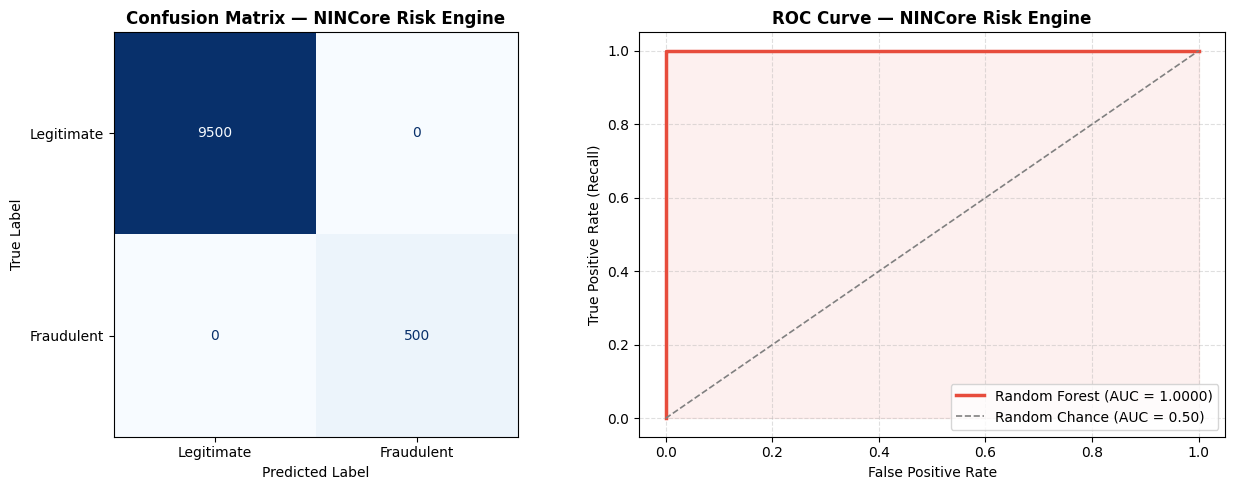

Plot saved.


In [6]:
# Cell 6 — Confusion Matrix & ROC Curve
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Confusion matrix
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Legitimate", "Fraudulent"]
)
disp.plot(ax=axes[0], colorbar=False, cmap="Blues")
axes[0].set_title("Confusion Matrix — NINCore Risk Engine",
                  fontweight="bold", fontsize=12)
axes[0].set_xlabel("Predicted Label")
axes[0].set_ylabel("True Label")

# ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
axes[1].plot(fpr, tpr, color="#e74c3c", linewidth=2.5,
             label=f"Random Forest (AUC = {roc_auc:.4f})")
axes[1].plot([0, 1], [0, 1], color="grey", linestyle="--",
             linewidth=1.2, label="Random Chance (AUC = 0.50)")
axes[1].fill_between(fpr, tpr, alpha=0.08, color="#e74c3c")
axes[1].set_xlabel("False Positive Rate")
axes[1].set_ylabel("True Positive Rate (Recall)")
axes[1].set_title("ROC Curve — NINCore Risk Engine",
                  fontweight="bold", fontsize=12)
axes[1].legend(loc="lower right")
axes[1].grid(linestyle="--", alpha=0.4)

plt.tight_layout()
plt.savefig(EVAL_PATH / "confusion_matrix_roc.png",
            dpi=150, bbox_inches="tight")
plt.show()
print("Plot saved.")

FEATURE IMPORTANCE — RANDOM FOREST

  Rank   Feature                      Importance        %
  -------------------------------------------------------
  1      Age_Consistency_Score            0.2892   28.92%  █████████████████████████████████████████████████████████
  2      Device_Reputation_Score          0.2080   20.80%  █████████████████████████████████████████
  3      Login_Frequency                  0.1774   17.74%  ███████████████████████████████████
  4      Failed_Auth_Attempts             0.0892    8.92%  █████████████████
  5      Geographic_Velocity              0.0718    7.18%  ██████████████
  6      Sector_Access_Frequency          0.0686    6.86%  █████████████
  7      Sector_Conflict_Flag             0.0360    3.60%  ███████
  8      Name_Mismatch_Flag               0.0306    3.06%  ██████
  9      Access_Hour                      0.0252    2.52%  █████
  10     NHIA_Status                      0.0019    0.19%  
  11     Gender                           0.0009    0

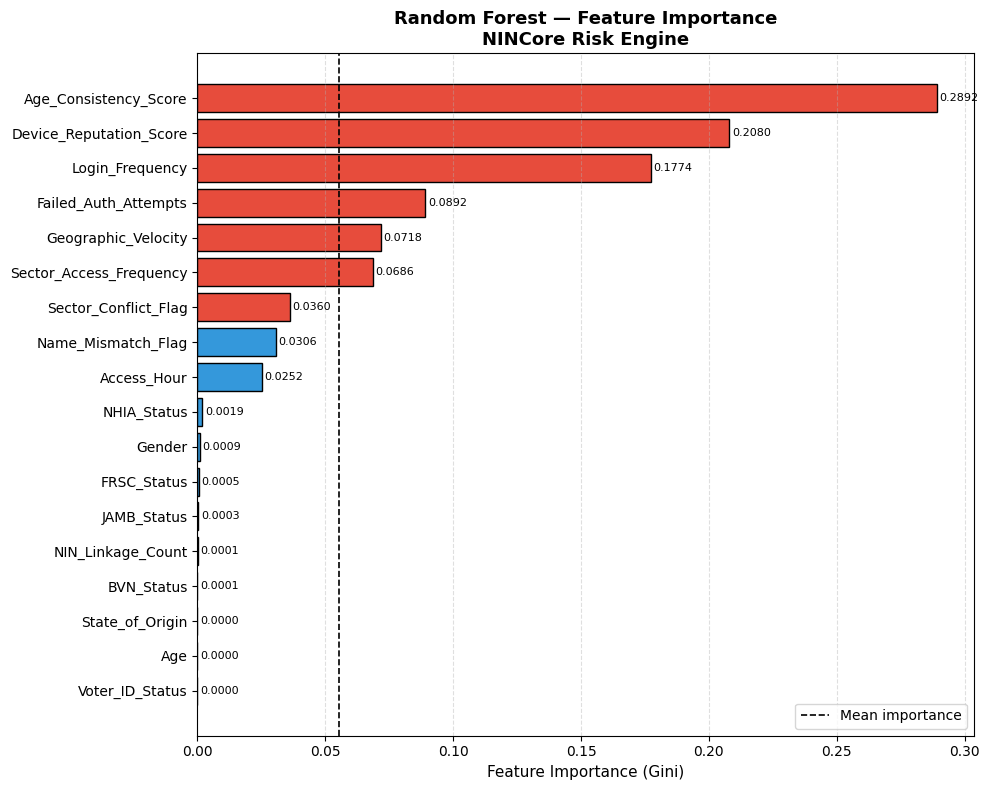

Plot saved.


In [7]:
# Cell 7 — Feature Importance
importances = rf_model.feature_importances_
feature_names = X.columns.tolist()

feat_df = pd.DataFrame({
    "Feature":    feature_names,
    "Importance": importances
}).sort_values("Importance", ascending=False).reset_index(drop=True)

feat_df["Rank"] = feat_df.index + 1
feat_df["Importance_%"] = (feat_df["Importance"] * 100).round(4)

print("=" * 55)
print("FEATURE IMPORTANCE — RANDOM FOREST")
print("=" * 55)
print(f"\n  {'Rank':<6} {'Feature':<28} {'Importance':>10} {'%':>8}")
print("  " + "-" * 55)
for _, row in feat_df.iterrows():
    bar = "█" * int(row["Importance"] * 200)
    print(f"  {int(row['Rank']):<6} {row['Feature']:<28} "
          f"{row['Importance']:>10.4f} {row['Importance_%']:>7.2f}%  {bar}")

# Plot
fig, ax = plt.subplots(figsize=(10, 8))
colors = ["#e74c3c" if i < 7 else "#3498db" for i in range(len(feat_df))]
ax.barh(feat_df["Feature"][::-1], feat_df["Importance"][::-1],
        color=colors[::-1], edgecolor="black")
ax.set_xlabel("Feature Importance (Gini)", fontsize=11)
ax.set_title("Random Forest — Feature Importance\nNINCore Risk Engine",
             fontsize=13, fontweight="bold")
ax.grid(axis="x", linestyle="--", alpha=0.4)
ax.axvline(x=feat_df["Importance"].mean(), color="black",
           linestyle="--", linewidth=1.2, label="Mean importance")
ax.legend()

# Add value labels
for i, (val, name) in enumerate(zip(feat_df["Importance"][::-1],
                                     feat_df["Feature"][::-1])):
    ax.text(val + 0.001, i, f"{val:.4f}", va="center", fontsize=8)

plt.tight_layout()
plt.savefig(EVAL_PATH / "feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()
print("Plot saved.")

In [8]:
# Cell 8 — Cross Validation
from sklearn.model_selection import StratifiedKFold, cross_validate

print("=" * 55)
print("5-FOLD STRATIFIED CROSS VALIDATION")
print("=" * 55)
print("Running on full SMOTE-balanced training set...")

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

scoring = ["accuracy", "precision", "recall", "f1", "roc_auc"]

cv_results = cross_validate(
    RandomForestClassifier(
        n_estimators=200, max_depth=20,
        min_samples_split=5, min_samples_leaf=2,
        max_features="sqrt", class_weight="balanced",
        random_state=RANDOM_STATE, n_jobs=-1
    ),
    X_train_sm, y_train_sm,
    cv=cv, scoring=scoring,
    return_train_score=False,
    verbose=0
)

print(f"\n  {'Metric':<12} {'Fold 1':>8} {'Fold 2':>8} {'Fold 3':>8} "
      f"{'Fold 4':>8} {'Fold 5':>8} {'Mean':>8} {'Std':>8}")
print("  " + "-" * 72)

for metric in scoring:
    scores = cv_results[f"test_{metric}"]
    print(f"  {metric:<12} " +
          " ".join(f"{s:>8.4f}" for s in scores) +
          f" {scores.mean():>8.4f} {scores.std():>8.4f}")

5-FOLD STRATIFIED CROSS VALIDATION
Running on full SMOTE-balanced training set...

  Metric         Fold 1   Fold 2   Fold 3   Fold 4   Fold 5     Mean      Std
  ------------------------------------------------------------------------
  accuracy       1.0000   1.0000   1.0000   1.0000   1.0000   1.0000   0.0000
  precision      1.0000   1.0000   1.0000   1.0000   1.0000   1.0000   0.0000
  recall         1.0000   1.0000   1.0000   1.0000   1.0000   1.0000   0.0000
  f1             1.0000   1.0000   1.0000   1.0000   1.0000   1.0000   0.0000
  roc_auc        1.0000   1.0000   1.0000   1.0000   1.0000   1.0000   0.0000
